In [27]:
%load_ext autoreload
%autoreload 2


import pandas as pd
import torch
from torch.utils.data import DataLoader
from dataset import CustomDataset
from dnn_model import DnnWOTransformer
import torch.nn as nn

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
from sklearn.metrics import ndcg_score
import scipy.stats as stats
import numpy as np

In [29]:
csv_path = "tables\\trkeDID_pits_over2.csv" 
all_data = pd.read_csv(csv_path)
all_data = all_data.fillna(-1)

In [30]:
#all_data = all_data[all_data['season'] > 2018]

In [31]:
all_data.columns = all_data.columns.str.strip()
categorical_cols = ['constructor', 'driverId', 'race_name',
                                'circuit']

numerical_cols = ['season', 'round', 'position_quali', 'grid',
                  'number_of_laps', 'number_of_corners', 'lap_length', 
                  'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 
                  'WindSpeed', 'rain_bin', 'wind_direction', 
                  'last_year_time', 'avg_position_last5', 
                  'num_dnfs_last5', 'avg_gained_lost_last5', 
                  'avg_pos_last5', 'avg_pit_duration_last5',
                  'avg_pit_duration_prev_race','avg_pit_duration_prev_driver_race', 
                  'avg_overtakes_prev_season_per_circuit', 'best_qual_time_ms']

In [32]:
target_col = 'position_race'
for col in categorical_cols:
    if all_data[col].dtype == 'object':  # ako je string tip
        all_data[col], uniques = pd.factorize(all_data[col])
        print(f"Kolona '{col}' kodirana u int. Broj unikatnih vrednosti: {len(uniques)}")

Kolona 'constructor' kodirana u int. Broj unikatnih vrednosti: 16
Kolona 'driverId' kodirana u int. Broj unikatnih vrednosti: 40
Kolona 'race_name' kodirana u int. Broj unikatnih vrednosti: 36
Kolona 'circuit' kodirana u int. Broj unikatnih vrednosti: 31


In [33]:
all_data[target_col] = all_data[target_col].apply(lambda x: -x)

In [34]:
batch_size = 4

In [35]:
embedding_dim = 8
num_numerical = len(numerical_cols)

In [36]:
dataset = CustomDataset(all_data, target_col, numerical_cols, categorical_cols)

loader_test = DataLoader(dataset, batch_size, shuffle=False)

In [37]:
embeddings_dict = {
    col: dataset.num_of_cat_features[col]
    for col in categorical_cols
}

In [38]:
hidden_dim = 512
dropout = 0.1
lr = 0.001

In [39]:
class ListNetLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred_scores, target_ranks):
        # Convert ranks to relevance (higher = better)
        #max_rank = target_ranks.max(dim=1, keepdim=True)[0]
        relevance = target_ranks #max_rank - target_ranks + 1  # shape: [B, N]

        # Compute probability distributions
        true_prob = torch.softmax(relevance, dim=1)
        pred_log_prob = torch.log_softmax(pred_scores, dim=1)

        # Cross entropy between predicted and true distributions
        loss = -torch.sum(true_prob * pred_log_prob, dim=1).mean()
        return loss


In [40]:
# class LambdaRank(nn.Module):
#     def __init__(self, net_structures, leaky_relu=False, sigma=1.0, double_precision=False):
#         """Fully Connected Layers with Sigmoid activation at the last layer

#         :param net_structures: list of int for LambdaRank FC width
#         """
#         super(LambdaRank, self).__init__()
#         self.fc_layers = len(net_structures)
#         for i in range(len(net_structures) - 1):
#             setattr(self, 'fc' + str(i + 1), nn.Linear(net_structures[i], net_structures[i+1]))
#             if leaky_relu:
#                 setattr(self, 'act' + str(i + 1), nn.LeakyReLU())
#             else:
#                 setattr(self, 'act' + str(i + 1), nn.ReLU())
#         setattr(self, 'fc' + str(len(net_structures)), nn.Linear(net_structures[-1], 1))
#         if double_precision:
#             for i in range(1, len(net_structures) + 1):
#                 setattr(self, 'fc' + str(i), getattr(self, 'fc' + str(i)).double())
#         self.sigma = sigma
#         # self.activation = nn.Sigmoid()
#         self.activation = nn.ReLU6()

#     def forward(self, input1):
#         # from 1 to N - 1 layer, use ReLU as activation function
#         for i in range(1, self.fc_layers):
#             fc = getattr(self, 'fc' + str(i))
#             act = getattr(self, 'act' + str(i))
#             input1 = act(fc(input1))

#         fc = getattr(self, 'fc' + str(self.fc_layers))
#         return self.activation(fc(input1)) * self.sigma


In [41]:
class RankNetLoss(nn.Module):
    def __init__(self):
        super(RankNetLoss, self).__init__()

    def forward(self, pred_scores, target_ranks):
        """
        pred_scores: [batch_size, num_drivers]
        target_ranks: [batch_size, num_drivers] (1 = najbolji, 20 = najgori)
        """
        batch_size, num_drivers = pred_scores.shape
        total_loss = 0.0

        for b in range(batch_size):
            scores = pred_scores[b]         # [num_drivers]
            ranks = target_ranks[b]         # [num_drivers]

            pair_loss = 0.0
            count = 0

            for i in range(num_drivers):
                for j in range(i + 1, num_drivers):
                    if ranks[i] == ranks[j]:
                        continue  # skip if ranks are same (no preference)

                    # Ground truth: 1 if i should beat j
                    S_ij = 1.0 if ranks[i] < ranks[j] else 0.0

                    s_i = scores[i]
                    s_j = scores[j]

                    pred_diff = s_i - s_j
                    prob = torch.sigmoid(pred_diff)

                    loss = - (S_ij * torch.log(prob + 1e-8) + (1 - S_ij) * torch.log(1 - prob + 1e-8))
                    pair_loss += loss
                    count += 1

            if count > 0:
                total_loss += pair_loss / count  # average over pairs

        return total_loss / batch_size


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ListNetNDCGLoss(nn.Module):

    def __init__(self, max_position=20):
        super(ListNetNDCGLoss, self).__init__()
        self.max_position = max_position  # najgora pozicija (za pretvaranje u relevance)

    def forward(self, pred_scores, true_positions):
        """
        Compute the ListNet-NDCG loss.

        Args:
            pred_scores: Tensor of shape [B, N] — model output scores for each driver
            true_positions: Tensor of shape [B, N] — true race positions (1 = first, 20 = last)

        Returns:
            Scalar loss.
        """
        batch_size, n = pred_scores.size()
        device = pred_scores.device

        # Convert positions to relevance scores
        relevance =  - true_positions  # shape: [B, N]
        gain = torch.pow(2.0, relevance.float()) - 1.0   # [B, N]

        # Softmax over relevance and log-softmax over predictions
        P_y = F.softmax(relevance.float(), dim=1)       # [B, N]
        P_z = F.log_softmax(pred_scores, dim=1)         # [B, N]

        # Weighted cross entropy (ListNet-NDCG loss)
        loss = -torch.sum(gain * P_y * P_z, dim=1)       # [B]
        return loss.mean()


In [43]:
# Load your data
df = all_data  # change to your actual path

# Sort by season and round to ensure chronological order
df = df.sort_values(by=["season", "round"]).reset_index(drop=True)

# Get all unique races
unique_races = df[["season", "round"]].drop_duplicates().reset_index(drop=True)
num_races = len(unique_races)

# Calculate split sizes
train_size = int(num_races * 0.65)
val_size = int(num_races * 0.1)+2
test_size = num_races - train_size - val_size 

# Split the races
train_races = unique_races.iloc[:train_size]
val_races = unique_races.iloc[train_size:train_size + val_size]
test_races = unique_races.iloc[train_size + val_size:]

# Use .merge to extract rows for each split
train_df = df.merge(train_races, on=["season", "round"])
val_df = df.merge(val_races, on=["season", "round"])
test_df = df.merge(test_races, on=["season", "round"])

In [44]:
print(val_size, test_size, train_size)

16 36 96


In [45]:
dataset_train = CustomDataset(train_df, target_col, numerical_cols, categorical_cols)
dataset_val = CustomDataset(val_df, target_col, numerical_cols, categorical_cols)
dataset_test =  CustomDataset(test_df, target_col, numerical_cols, categorical_cols)


loader_test = DataLoader(dataset_test, batch_size, shuffle=False)
loader_val = DataLoader(dataset_val, batch_size, shuffle=False)
loader_train = DataLoader(dataset_train, batch_size, shuffle=False)

In [46]:
from datetime import datetime
import os
timern = datetime.now().strftime('%d-%m-%Y_%H-%M-%S')
path = f'models_camp\\dnn\\{timern}'
os.mkdir(path)

In [47]:
path

'models_camp\\dnn\\30-06-2025_13-19-45'

In [48]:
model = DnnWOTransformer(embeddings_dict, num_numerical, embedding_dim, hidden_dim=hidden_dim, dropout_p=dropout)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = ListNetLoss()  
# optimizer = torch.optim.AdamW(model.parameters(), lr)
optimizer = torch.optim.SGD(model.parameters(), lr, weight_decay=0.0001)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = "max", factor = 0.75, patience = 10)

val_loss_list = []
ndcg_train = []
loss_list_train = []
loss_list_train = []
ndcg_values_valid = []
ndcg_values_valid_one_epoch = []


In [49]:
num_epochs = 250 + 1

In [ ]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    ndcg_values = []
    #ndcg_values_valid = []
    for batch_idx, (cat_features, num_tensor, target, drivers_num, position_quali) in enumerate(loader_train):
        cat_features = {k: v.to(device) for k, v in cat_features.items()}
        num_tensor = num_tensor.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        output = model(cat_features, num_tensor)  # [batch, 20, 1]
        scores = output.squeeze(-1)               # [batch, 20]

        # target su već rangovi (1 je najbolji), koristi direktno
        loss = criterion(scores, target)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        true_rank_np = target.cpu().numpy()
        scores_np = scores.cpu().detach().numpy()
        

        for i in range(true_rank_np.shape[0]):
            ndcg = ndcg_score([-true_rank_np[i]], [scores_np[i]], k=10)  # možeš i k=None za ceo poredak
            ndcg_values.append(ndcg)

    avg_loss = running_loss / len(loader_train)
    avg_ndcg = sum(ndcg_values) / len(ndcg_values)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, NDCG: {avg_ndcg:.4f}, lr: {lr}")




    model.eval()
    val_loss = 0.0
    ndcg_values_valid_one_epoch = []

    with torch.no_grad():
        for batch_idx, (cat_features, num_tensor, target, drivers_num, position_quali) in enumerate(loader_val):
            cat_features = {k: v.to(device) for k, v in cat_features.items()}
            num_tensor = num_tensor.to(device)
            target = target.to(device)

            output = model(cat_features, num_tensor).squeeze(-1)  # [batch, 20]
            loss = criterion(output, target)
            val_loss += loss.item()

            scores_np = output.cpu().numpy()
            true_rank_np = target.cpu().numpy()
            #true_relevance = 21 - true_rank_np

            for i in range(true_rank_np.shape[0]):
                ndcg = ndcg_score([-true_rank_np[i]], [scores_np[i]], k=10)
                ndcg_values_valid_one_epoch.append(ndcg)

    avg_val_loss = val_loss / len(loader_val)
    avg_ndcg_valid = sum(ndcg_values_valid_one_epoch) / len(ndcg_values_valid_one_epoch)
    
    scheduler.step(avg_val_loss)

    print(f"Validacioni loss: {avg_val_loss:.4f}")
    print(f"Validacioni NDCG: {avg_ndcg_valid:.4f}")

    val_loss_list.append(avg_val_loss)
    ndcg_values_valid.append(avg_ndcg_valid)

    ndcg_valid = ndcg / len(loader_val)
    avg_val_loss = val_loss / len(ndcg_values_valid_one_epoch)
    


    loss_list_train.append(avg_loss)
    ndcg_train.append(avg_ndcg)
    if epoch % 5 == 0:
        torch.save(model.state_dict(), os.path.join(path, f'{epoch}.pth'))
        print(f'Saved to models {epoch}.pth')



Epoch 1/251, Loss: 2.9940, NDCG: 0.5830, lr: 0.001
Validacioni loss: 2.9933
Validacioni NDCG: 0.5815
Saved to models 0.pth
Epoch 2/251, Loss: 2.9938, NDCG: 0.5888, lr: 0.001
Validacioni loss: 2.9931
Validacioni NDCG: 0.5673
Epoch 3/251, Loss: 2.9936, NDCG: 0.5825, lr: 0.001
Validacioni loss: 2.9928
Validacioni NDCG: 0.5714
Epoch 4/251, Loss: 2.9931, NDCG: 0.5823, lr: 0.001
Validacioni loss: 2.9924
Validacioni NDCG: 0.5562
Epoch 5/251, Loss: 2.9933, NDCG: 0.5849, lr: 0.001
Validacioni loss: 2.9919
Validacioni NDCG: 0.5781
Epoch 6/251, Loss: 2.9922, NDCG: 0.5818, lr: 0.001
Validacioni loss: 2.9916
Validacioni NDCG: 0.5861
Saved to models 5.pth
Epoch 7/251, Loss: 2.9918, NDCG: 0.5851, lr: 0.001
Validacioni loss: 2.9913
Validacioni NDCG: 0.5940
Epoch 8/251, Loss: 2.9920, NDCG: 0.5774, lr: 0.001
Validacioni loss: 2.9910
Validacioni NDCG: 0.6002
Epoch 9/251, Loss: 2.9914, NDCG: 0.5745, lr: 0.001
Validacioni loss: 2.9907
Validacioni NDCG: 0.6003
Epoch 10/251, Loss: 2.9910, NDCG: 0.5780, lr: 0

In [51]:
len(dataset_train)

96

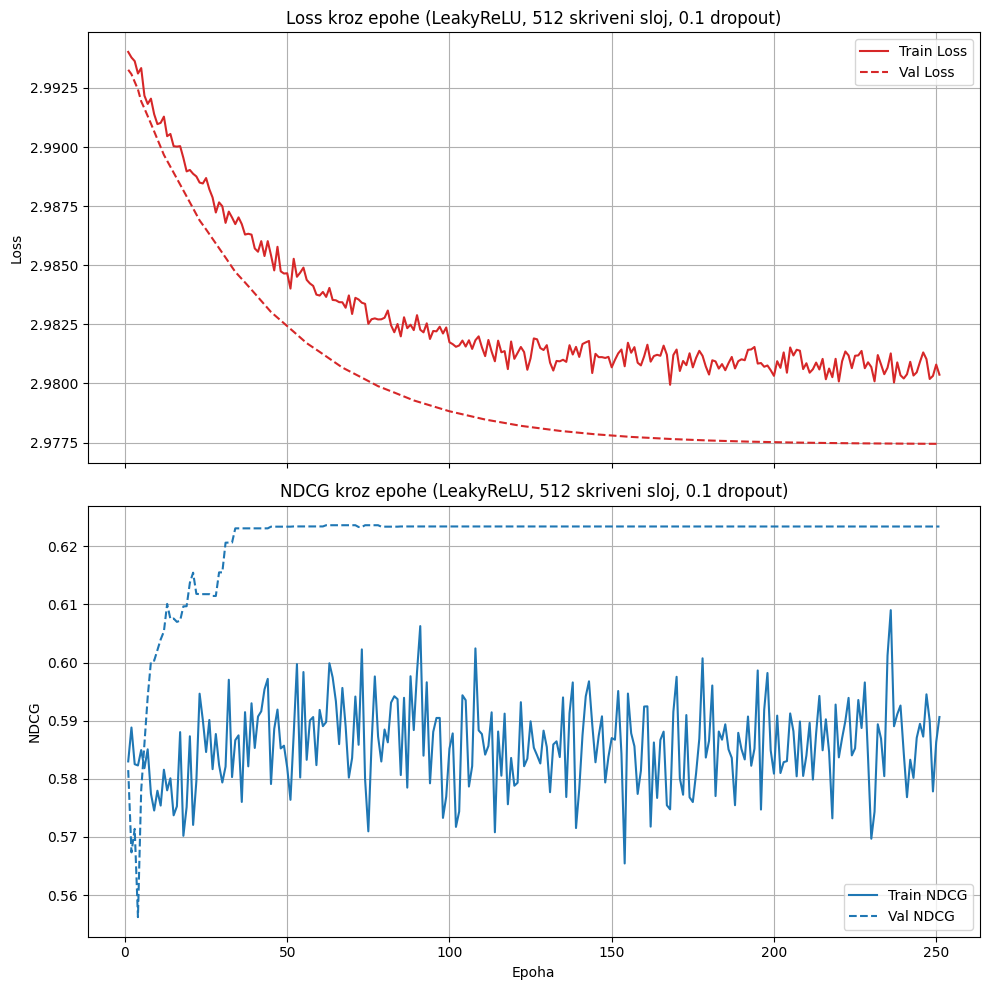

In [52]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(loss_list_train) + 1))

fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Prvi subplot – Loss
axs[0].plot(epochs, loss_list_train, label='Train Loss', color='tab:red', linestyle='-')
axs[0].plot(epochs, val_loss_list, label='Val Loss', color='tab:red', linestyle='--')
axs[0].set_ylabel('Loss')
axs[0].set_title(f'Loss kroz epohe (LeakyReLU, {hidden_dim} skriveni sloj, {dropout} dropout)')
axs[0].legend()
axs[0].grid(True)

# Drugi subplot – NDCG
axs[1].plot(epochs, ndcg_train, label='Train NDCG', color='tab:blue', linestyle='-')
axs[1].plot(epochs, ndcg_values_valid, label='Val NDCG', color='tab:blue', linestyle='--')
axs[1].set_xlabel('Epoha')
axs[1].set_ylabel('NDCG')
axs[1].set_title(f'NDCG kroz epohe (LeakyReLU, {hidden_dim} skriveni sloj, {dropout} dropout)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [53]:
fig.savefig(os.path.join(path, 'metrike.jpg'))

In [54]:
path

'models_camp\\dnn\\30-06-2025_13-19-45'

In [55]:
model_last = model

In [56]:
# 1. Re-instantiate the model
model = DnnWOTransformer(embeddings_dict, num_numerical, embedding_dim=embedding_dim, hidden_dim=hidden_dim, dropout_p=dropout)

# 2. Load the saved weights
model.load_state_dict(torch.load(os.path.join(path, input('koji model zelite')), map_location='cpu'))

# 3. Set to eval or train as needed
model.eval()  # or model.train()


FileNotFoundError: [Errno 2] No such file or directory: 'models_camp\\dnn\\30-06-2025_13-19-45\\'

In [ ]:
from scipy import stats
import numpy as np
from sklearn.metrics import ndcg_score

# Pomerimo sve na CPU i u NumPy
try:
    true_rank_np = target.cpu().numpy()  # [batch, 20]
    scores_np = scores.cpu().detach().numpy()  # [batch, 20]
except:
    true_rank_np = target
    scores_np = scores


# Invertujemo rang: pozicija 1 → 20, pozicija 20 → 1
true_relevance = - true_rank_np

ndcg_values = []
tau_list = []
spearman_list = []

for i in range(true_relevance.shape[0]):
    ndcg = ndcg_score([true_relevance[i]], [scores_np[i]], k=10)
    ndcg_values.append(ndcg)

    # Ove dve linije su bile pogrešne – treba koristiti po-trci podatke
    tau, _ = stats.kendalltau(true_rank_np[i], -scores_np[i])
    spearman, _ = stats.spearmanr(true_rank_np[i], -scores_np[i])
    tau_list.append(tau)
    spearman_list.append(spearman)

avg_ndcg = np.mean(ndcg_values)
avg_tau = np.nanmean(tau_list)
avg_spearman = np.nanmean(spearman_list)

print(f"Average NDCG@10: {avg_ndcg:.4f}")
print(f"Average Kendall's Tau: {avg_tau:.4f}")
print(f"Average Spearman: {avg_spearman:.4f}")


Average NDCG@10: 0.6165
Average Kendall's Tau: -0.0342
Average Spearman: -0.0635


In [ ]:
race_index = 13  # npr. 5. trka (indeks 4)

with torch.no_grad():
    for batch_idx, (cat_features, num_tensor, target, drivers_num, position_quali) in enumerate(loader_test):
        if race_index // batch_size == batch_idx:
            sample_idx = race_index % batch_size  # indeks unutar batcha

            cat_features = {k: v.to(device) for k, v in cat_features.items()}
            num_tensor = num_tensor.to(device)
            target = target.to(device)

            output = model(cat_features, num_tensor).squeeze(-1)

            # Izvuci samo jednu trku iz batcha
            scores = output[sample_idx].cpu().numpy()
            true_ranks = target[sample_idx].cpu().numpy()
            quali_pos = position_quali[sample_idx].numpy()
            driver_ids = drivers_num[sample_idx].numpy()

            # Sortiraj po predikcijama
            pred_order = scores.argsort()

            print(f"Poređenje za trku #{race_index}:\n")
            print(f"{'Poz':<5}{'Vozač':<10}{'Stvarna':<10}{'Predviđena':<12}{'Kvalifikacije':<15}")
            for pos, idx in enumerate(pred_order):
                print(f"{pos+1:<5}{driver_ids[idx]:<10}{true_ranks[idx]:<10}{pos+1:<12}{quali_pos[idx]:<15}")
            break


Poređenje za trku #13:

Poz  Vozač     Stvarna   Predviđena  Kvalifikacije  
1    16        -4.0      1           2              
2    4         -6.0      2           7              
3    81        -8.0      3           8              
4    3         -13.0     4           14             
5    27        -16.0     5           10             
6    20        -12.0     6           15             
7    2         -20.0     7           18             
8    24        -11.0     8           17             
9    31        -17.0     9           19             
10   33        -1.0      10          1              
11   11        -2.0      11          5              
12   14        -9.0      12          6              
13   55        -3.0      13          4              
14   44        -7.0      14          9              
15   18        -10.0     15          12             
16   63        -5.0      16          3              
17   77        -19.0     17          16             
18   10        -18.0  

In [ ]:
race_index = 15  # npr. 15. trka

with torch.no_grad():
    for batch_idx, (cat_features, num_tensor, target, drivers_num, position_quali) in enumerate(loader_test):
        if race_index // batch_size == batch_idx:
            sample_idx = race_index % batch_size

            cat_features = {k: v.to(device) for k, v in cat_features.items()}
            num_tensor = num_tensor.to(device)
            target = target.to(device)

            output = model(cat_features, num_tensor).squeeze(-1)

            scores = output[sample_idx].cpu().numpy()
            true_ranks = target[sample_idx].cpu().numpy()
            quali_pos = position_quali[sample_idx].numpy()
            driver_ids = drivers_num[sample_idx].numpy()

            # Prvo pripremimo listu
            result = []
            for i in range(len(driver_ids)):
                result.append({
                    "driver_id": driver_ids[i],
                    "score": scores[i],
                    "true_rank": true_ranks[i],
                    "quali": quali_pos[i]
                })

            # Sortiramo po score da bismo znali ko je prvi po modelu
            sorted_by_score = sorted(result, key=lambda x: x["score"])
            for pred_pos, item in enumerate(sorted_by_score):
                item["predicted_position"] = pred_pos + 1  # 1-based pozicija

            # Sada možemo sortirati po predikciji i ispisati to
            final_result = sorted(sorted_by_score, key=lambda x: x["predicted_position"])

            print(f"Poređenje za trku #{race_index}:\n")
            print(f"{'Poz':<5}{'DriverID':<10}{'Stvarna':<10}{'Predviđena':<12}{'Kvalifikacije':<15}")
            for entry in final_result:
                print(f"{entry['predicted_position']:<5}{entry['driver_id']:<10}{int(entry['true_rank']):<10}{entry['predicted_position']:<12}{entry['quali']:<15}")
            break


Poređenje za trku #15:

Poz  DriverID  Stvarna   Predviđena  Kvalifikacije  
1    2         -17       1           19             
2    24        -18       2           20             
3    20        -13       3           18             
4    18        -12       4           16             
5    23        -20       5           14             
6    77        -14       6           13             
7    3         -19       7           11             
8    27        -11       8           12             
9    22        -10       9           10             
10   11        -2        10          2              
11   33        -1        11          1              
12   4         -5        12          3              
13   81        -8        13          6              
14   16        -4        14          8              
15   44        -9        15          7              
16   55        -3        16          4              
17   63        -7        17          9              
18   14        -6     